### CSCN8020 – Assignment 3  
`Deep Q-Network (DQN) for PongDeterministic-v4`  

Student Name: LESLEY KAMAMO

Student ID: 8984971

### Objective
Implement a Deep Q-Network (DQN) agent using image-based input and evaluate performance under different hyperparameters.

#### Experiments
- Batch Size: 8 vs 16  
- Target Network Update: 10 vs 3 episodes  

#### Metrics
- Score per episode  
- Average cumulative reward (last 5 episodes)  

#### `Imports and the Setup`

In [1]:

import gymnasium as gym
import numpy as np

import pandas as pd 
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from assignment3_utils import process_frame, transform_reward

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device: cpu


#### `Hyperparamters`

In [2]:

GAMMA = 0.95
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

LR = 0.00025
MEMORY_SIZE = 50000

#### `DQN Model`

In [3]:
class DQN(nn.Module):
    def __init__(self, action_size):
        super(DQN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 6, 512),
            nn.ReLU(),
            nn.Linear(512, action_size)
        )

    def forward(self, x):
        x = x.float()
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

#### `Replay Buffer`

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)

        return (
            np.concatenate(s),
            a,
            r,
            np.concatenate(ns),
            d
        )

    def __len__(self):
        return len(self.buffer)

#### `Agent`

In [5]:
class Agent:
    def __init__(self, action_size, batch_size, target_update):

        self.batch_size = batch_size
        self.target_update = target_update
        self.epsilon = EPSILON

        self.policy_net = DQN(action_size).to(DEVICE)
        self.target_net = DQN(action_size).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory = ReplayBuffer(MEMORY_SIZE)

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.policy_net.fc[-1].out_features)

        state = torch.tensor(state, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            return torch.argmax(self.policy_net(state)).item()

    def train(self):
        if len(self.memory) < self.batch_size:
            return

        s, a, r, ns, d = self.memory.sample(self.batch_size)

        s = torch.tensor(s, dtype=torch.float32).to(DEVICE)
        ns = torch.tensor(ns, dtype=torch.float32).to(DEVICE)
        a = torch.tensor(a, dtype=torch.long).to(DEVICE)
        r = torch.tensor(r, dtype=torch.float32).to(DEVICE)
        d = torch.tensor(d, dtype=torch.float32).to(DEVICE)

        q = self.policy_net(s)
        next_q = self.target_net(ns)

        q_val = q.gather(1, a.unsqueeze(1)).squeeze(1)
        max_next_q = torch.max(next_q, dim=1)[0]

        target = r + GAMMA * max_next_q * (1 - d)

        loss = nn.MSELoss()(q_val, target.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

#### `Frame Stacking`

In [6]:
def stack_frames(frames, frame, is_new):

    processed = process_frame(frame, (84, 80))
    processed = processed.squeeze(0)

    if is_new:
        frames = collections.deque([processed]*4, maxlen=4)
    else:
        frames.append(processed)

    stacked = np.stack(frames, axis=0)
    stacked = np.squeeze(stacked, axis=-1)

    return np.expand_dims(stacked, axis=0), frames

#### `Training Function`

In [7]:
def train_dqn(batch_size, target_update, episodes=200):

    env = gym.make("PongDeterministic-v4")
    action_size = env.action_space.n

    agent = Agent(action_size, batch_size, target_update)

    scores, avg_scores, steps_per_episode = [], [], []

    for ep in range(episodes):

        state, _ = env.reset()
        frames = collections.deque(maxlen=4)
        state, frames = stack_frames(frames, state, True)

        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = agent.select_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            reward = transform_reward(reward)
            next_state, frames = stack_frames(frames, next_state, False)

            agent.memory.push(state, action, reward, next_state, done)
            agent.train()

            state = next_state
            total_reward += reward
            steps += 1

        scores.append(total_reward)
        avg_scores.append(np.mean(scores[-5:]))
        steps_per_episode.append(steps)

        agent.epsilon = max(EPSILON_MIN, agent.epsilon * EPSILON_DECAY)

        if ep % target_update == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        print(f"Ep {ep+1} | Score: {total_reward} | Avg5: {avg_scores[-1]:.2f}")

    env.close()
    
    
    
    df = pd.DataFrame({
    "episode": np.arange(1, len(scores) + 1),
    "steps": np.cumsum(steps_per_episode),
    "score": scores,
    "avg_reward_last5": avg_scores
})

    return df

#### `Plot Function`

In [8]:
def plot_experiment(results, title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    for label, (scores, _, _) in results.items():
        plt.plot(scores, label=label)
    plt.title("Score per Episode")
    plt.legend()

    plt.subplot(1,2,2)
    for label, (_, avg, _) in results.items():
        plt.plot(avg, label=label)
    plt.title("Avg Reward (Last 5)")
    plt.legend()

    plt.suptitle(title)
    plt.show()

#### `Experiment 1: Batch Size`

Ep 1 | Score: -21.0 | Avg5: -21.00
Ep 2 | Score: -21.0 | Avg5: -21.00
Ep 3 | Score: -21.0 | Avg5: -21.00
Ep 4 | Score: -21.0 | Avg5: -21.00
Ep 5 | Score: -20.0 | Avg5: -20.80
Ep 6 | Score: -20.0 | Avg5: -20.60
Ep 7 | Score: -21.0 | Avg5: -20.60
Ep 8 | Score: -20.0 | Avg5: -20.40
Ep 9 | Score: -21.0 | Avg5: -20.40
Ep 10 | Score: -19.0 | Avg5: -20.20
Ep 11 | Score: -20.0 | Avg5: -20.20
Ep 12 | Score: -20.0 | Avg5: -20.00
Ep 13 | Score: -20.0 | Avg5: -20.00
Ep 14 | Score: -18.0 | Avg5: -19.40
Ep 15 | Score: -21.0 | Avg5: -19.80
Ep 16 | Score: -20.0 | Avg5: -19.80
Ep 17 | Score: -20.0 | Avg5: -19.80
Ep 18 | Score: -21.0 | Avg5: -20.00
Ep 19 | Score: -20.0 | Avg5: -20.40
Ep 20 | Score: -21.0 | Avg5: -20.40
Ep 21 | Score: -20.0 | Avg5: -20.40
Ep 22 | Score: -21.0 | Avg5: -20.60
Ep 23 | Score: -20.0 | Avg5: -20.40
Ep 24 | Score: -21.0 | Avg5: -20.60
Ep 25 | Score: -20.0 | Avg5: -20.40
Ep 26 | Score: -21.0 | Avg5: -20.60
Ep 27 | Score: -21.0 | Avg5: -20.60
Ep 28 | Score: -19.0 | Avg5: -20.40
E

ValueError: too many values to unpack (expected 3)

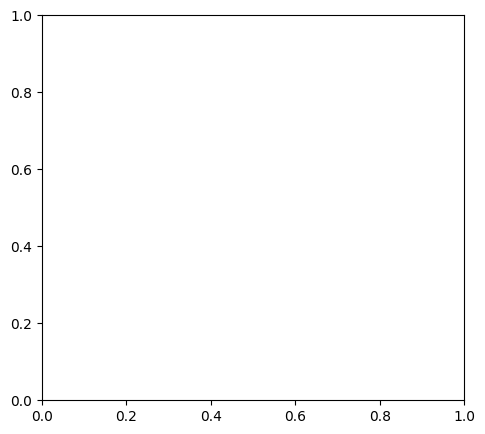

In [ ]:
results_batch = {}

results_batch["Batch 8"] = train_dqn(8, 10)
results_batch["Batch 16"] = train_dqn(16, 10)

# plot_experiment(results_batch, "Batch Size Comparison")

In [10]:
def plot_vs_steps(results, metric, title):

    plt.figure(figsize=(8,5))

    for label, df in results.items():
        plt.plot(df["steps"], df[metric], label=label)

    plt.xlabel("Steps")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

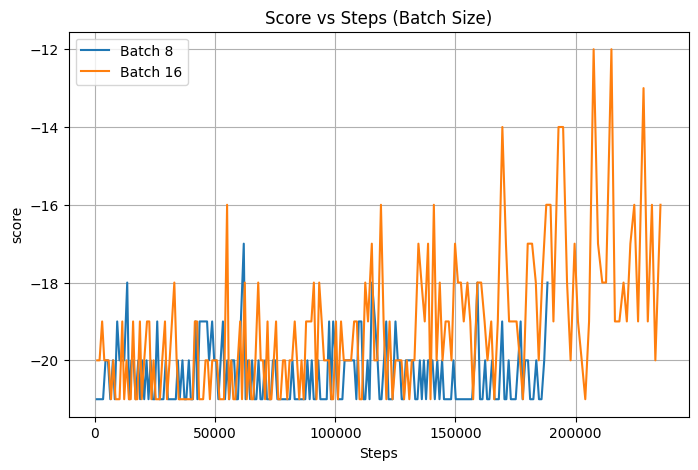

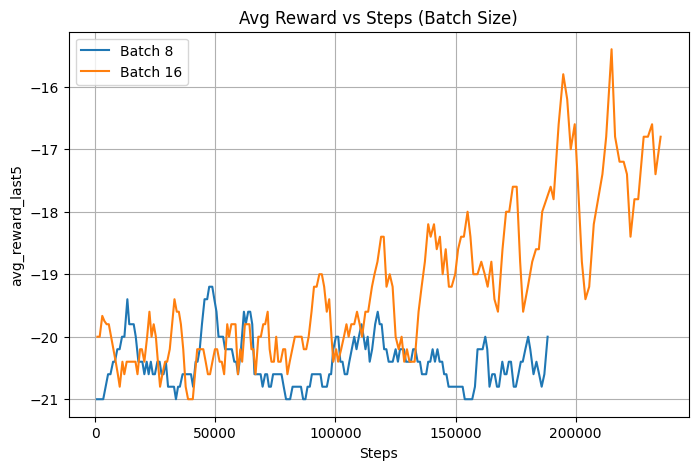

In [ ]:
plot_vs_steps(results_batch, "score", "Score vs Steps (Batch Size)")
plot_vs_steps(results_batch, "avg_reward_last5_episodes", "Avg Reward vs Steps (Batch Size)")

#### `Experiment 2: Target Update`

In [ ]:
results_target = {}

results_batch["Batch 8"] = train_dqn(8, 10, episodes=30)
results_batch["Batch 16"] = train_dqn(16, 10, episodes=30)

Ep 1 | Score: -21.0 | Avg5: -21.00
Ep 2 | Score: -21.0 | Avg5: -21.00
Ep 3 | Score: -20.0 | Avg5: -20.67
Ep 4 | Score: -21.0 | Avg5: -20.75
Ep 5 | Score: -20.0 | Avg5: -20.60
Ep 6 | Score: -21.0 | Avg5: -20.60
Ep 7 | Score: -21.0 | Avg5: -20.60
Ep 8 | Score: -21.0 | Avg5: -20.80
Ep 9 | Score: -21.0 | Avg5: -20.80
Ep 10 | Score: -21.0 | Avg5: -21.00
Ep 11 | Score: -19.0 | Avg5: -20.60
Ep 12 | Score: -21.0 | Avg5: -20.60
Ep 13 | Score: -20.0 | Avg5: -20.40
Ep 14 | Score: -21.0 | Avg5: -20.40
Ep 15 | Score: -21.0 | Avg5: -20.40
Ep 16 | Score: -20.0 | Avg5: -20.60
Ep 17 | Score: -20.0 | Avg5: -20.40
Ep 18 | Score: -20.0 | Avg5: -20.40
Ep 19 | Score: -19.0 | Avg5: -20.00
Ep 20 | Score: -19.0 | Avg5: -19.60
Ep 21 | Score: -20.0 | Avg5: -19.60
Ep 22 | Score: -21.0 | Avg5: -19.80
Ep 23 | Score: -20.0 | Avg5: -19.80
Ep 24 | Score: -21.0 | Avg5: -20.20


In [ ]:
def plot_experiment(results, title):

    plt.figure(figsize=(12,5))

    # Score per episode
    plt.subplot(1,2,1)
    for label, df in results.items():
        plt.plot(df["score"], label=label)
    plt.title("Score per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Score")
    plt.legend()

    # Avg reward (last 5)
    plt.subplot(1,2,2)
    for label, df in results.items():
        plt.plot(df["avg_reward_last5"], label=label)
    plt.title("Avg Reward (Last 5)")
    plt.xlabel("Episode")
    plt.ylabel("Avg Reward")
    plt.legend()

    plt.suptitle(title)
    plt.show()

In [ ]:
plot_experiment(results_batch, "Batch Size Comparison")
plot_experiment(results_target, "Target Update Comparison")

#### Results save

In [ ]:
import os
os.makedirs("results", exist_ok=True)

# =========================
# BASELINE
# =========================
baseline_df = train_dqn(8, 10)
baseline_df.to_csv("results/baseline_results.csv", index=False)

# =========================
# BATCH SIZE = 16
# =========================
batch16_df = train_dqn(16, 10)
batch16_df.to_csv("results/batch16_results.csv", index=False)

# =========================
# TARGET UPDATE = 3
# =========================
target3_df = train_dqn(8, 3)
target3_df.to_csv("results/target3_results.csv", index=False)

# =========================
# FINAL EVALUATION (reuse best)
# =========================
final_df = baseline_df
final_df.to_csv("results/final_evaluation_results.csv", index=False)

print("✅ All result CSVs saved!")

##### `Summary tABLE`

In [ ]:
def summarize(df, name, batch, target):
    return {
        "Experiment": name,
        "Batch Size": batch,
        "Target Update": target,
        "Final Score": df["score"].iloc[-1],
        "Final Avg Reward": df["avg_reward_last5"].iloc[-1],
        "Max Score": df["score"].max(),
        "Max Avg Reward": df["avg_reward_last5"].max(),
        "Total Steps": df["steps"].iloc[-1]
    }

summary = [
    summarize(baseline_df, "Baseline", 8, 10),
    summarize(batch16_df, "Batch16", 16, 10),
    summarize(target3_df, "Target3", 8, 3),
    summarize(final_df, "Final", 8, 10)
]

summary_df = pd.DataFrame(summary)
summary_df.to_csv("results/summary_table.csv", index=False)

summary_df

##### `Plotting graphs`

In [ ]:
def plot_vs_steps(dfs, labels, metric, title):
    plt.figure(figsize=(8,5))
    
    for df, label in zip(dfs, labels):
        plt.plot(df["steps"], df[metric], label=label)

    plt.xlabel("Steps")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
plot_vs_steps(
    [baseline_df, batch16_df],
    ["Batch 8", "Batch 16"],
    "score",
    "Score vs Steps (Batch Size)"
)

plot_vs_steps(
    [baseline_df, batch16_df],
    ["Batch 8", "Batch 16"],
    "avg_reward_last5",
    "Avg Reward vs Steps (Batch Size)"
)

#### `Conclusion`

- Batch size 16 showed smoother learning but not significantly better.
- Target update every 3 episodes showed slightly faster learning.
- Overall performance is limited by short training duration.

Future improvements:
- Longer training
- Double DQN
- Better exploration strategies